# AV1 - Apoio à Decisão para Campanhas Educativas no Trânsito
## Árvore de Decisão aplicada a Sinistros de Trânsito PRF 2025

**Curso:** Sistemas de Informação  
**Disciplina:** Sistemas de Apoio à Decisão  

---

### Questão Gerencial
> *Quais características dos sinistros estão mais associadas à ocorrência de vítimas e devem ser priorizadas como foco de campanhas educativas e ações preventivas?*

### Modelo Utilizado
**Árvore de Decisão** com critério **Entropia / Ganho de Informação** (equivalente ao algoritmo ID3/C4.5).

O ganho de informação mede a redução de entropia ao particionar os dados por um atributo:

$$IG(S, A) = Entropia(S) - \sum_{x \in P(A)} \frac{|S_x|}{|S|} \cdot Entropia(S_x)$$

O atributo com **maior ganho de informação** é escolhido para dividir o nó.

---

## 0. Importações e Configurações

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# Estilo dos gráficos
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid', palette='muted')

# Configurações do modelo
RANDOM_STATE = 42
MAX_DEPTH    = 7
MIN_SAMPLES_LEAF = 50
TEST_SIZE    = 0.20

FEATURES = [
    'dia_semana', 'fase_dia', 'condicao_metereologica',
    'tipo_pista', 'tracado_via', 'causa_acidente',
    'tipo_acidente', 'uso_solo', 'sentido_via', 'uf'
]

COLUNA_ALVO = 'classificacao_acidente'

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


---
## 1. Carregamento dos Dados

**Fonte:** Portal de Dados Abertos do Governo Federal - PRF  
**Arquivo:** `datatran2025.csv` (sinistros agrupados por ocorrência, 2025)  
**Encoding:** `latin-1` (padrão de CSVs do governo brasileiro)  
**Separador:** `;`

In [2]:
# ── Detecta ambiente ──────────────────────────────────────────────────
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Opção A: Upload direto (abre janela para selecionar o arquivo)
    from google.colab import files
    print("Selecione o arquivo datatran2025.csv para fazer upload...")
    uploaded = files.upload()          # abre o seletor de arquivo
    CSV_PATH = list(uploaded.keys())[0]

    # Opção B (alternativa): montar o Google Drive
    # from google.colab import drive
    # drive.mount('/content/drive')
    # CSV_PATH = '/content/drive/MyDrive/datatran2025.csv'  # ajuste o caminho
else:
    # Ambiente local: busca na raiz ou em data/
    for caminho in ['datatran2025.csv', 'data/datatran2025.csv', 'data/sinistros_2025.csv']:
        if os.path.exists(caminho):
            CSV_PATH = caminho
            break
    else:
        raise FileNotFoundError("Arquivo datatran2025.csv não encontrado.")

# ── Cria pasta output se não existir ─────────────────────────────────
os.makedirs('output', exist_ok=True)

df = pd.read_csv(CSV_PATH, sep=';', encoding='latin-1', low_memory=False)

print(f'Registros : {len(df):,}')
print(f'Colunas   : {df.shape[1]}')
print(f'\nColunas disponíveis:')
print(df.columns.tolist())

Registros : 72,529
Colunas   : 30

Colunas disponíveis:
['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


In [3]:
# Primeiras linhas do dataset
df[['dia_semana', 'fase_dia', 'causa_acidente', 'tipo_acidente',
    'condicao_metereologica', 'tipo_pista', 'classificacao_acidente']].head(8)

,dia_semana,fase_dia,causa_acidente,tipo_acidente,condicao_metereologica,tipo_pista,classificacao_acidente
0,quarta-feira,Pleno dia,Reação tardia ou ineficiente do condutor,Tombamento,Céu Claro,Múltipla,Com Vítimas Feridas
1,quarta-feira,Pleno dia,Pista esburacada,Colisão frontal,Céu Claro,Simples,NaN
2,quarta-feira,Pleno dia,Reação tardia ou ineficiente do condutor,Colisão traseira,Sol,Dupla,Com Vítimas Feridas
3,quarta-feira,Pleno dia,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Céu Claro,Dupla,Com Vítimas Feridas
4,quarta-feira,Pleno dia,Velocidade Incompatível,Colisão frontal,Chuva,Simples,Com Vítimas Feridas
5,quarta-feira,Pleno dia,Transitar na contramão,Colisão frontal,Céu Claro,Simples,Com Vítimas Fatais
6,quarta-feira,Pleno dia,Ausência de reação do condutor,Saída de leito carroçável,Céu Claro,Dupla,Com Vítimas Feridas
7,quarta-feira,Pleno dia,Ausência de reação do condutor,Colisão traseira,Nublado,Dupla,Com Vítimas Feridas


---
## 2. Exploração dos Dados (EDA)

### 2.1 Variável Alvo: `classificacao_acidente`

In [4]:
# Distribuição da variável alvo
dist_alvo = df[COLUNA_ALVO].value_counts(dropna=False)
print('Distribuição da classificação dos sinistros:')
print(dist_alvo.to_string())
print(f'\nTotal com classificação válida: {dist_alvo.dropna().sum():,}')
print(f'Registros sem classificação (NaN): {df[COLUNA_ALVO].isna().sum()}')

Distribuição da classificação dos sinistros:
classificacao_acidente
Com Vítimas Feridas    56181
Sem Vítimas            11138
Com Vítimas Fatais      5209
NaN                        1

Total com classificação válida: 72,529
Registros sem classificação (NaN): 1


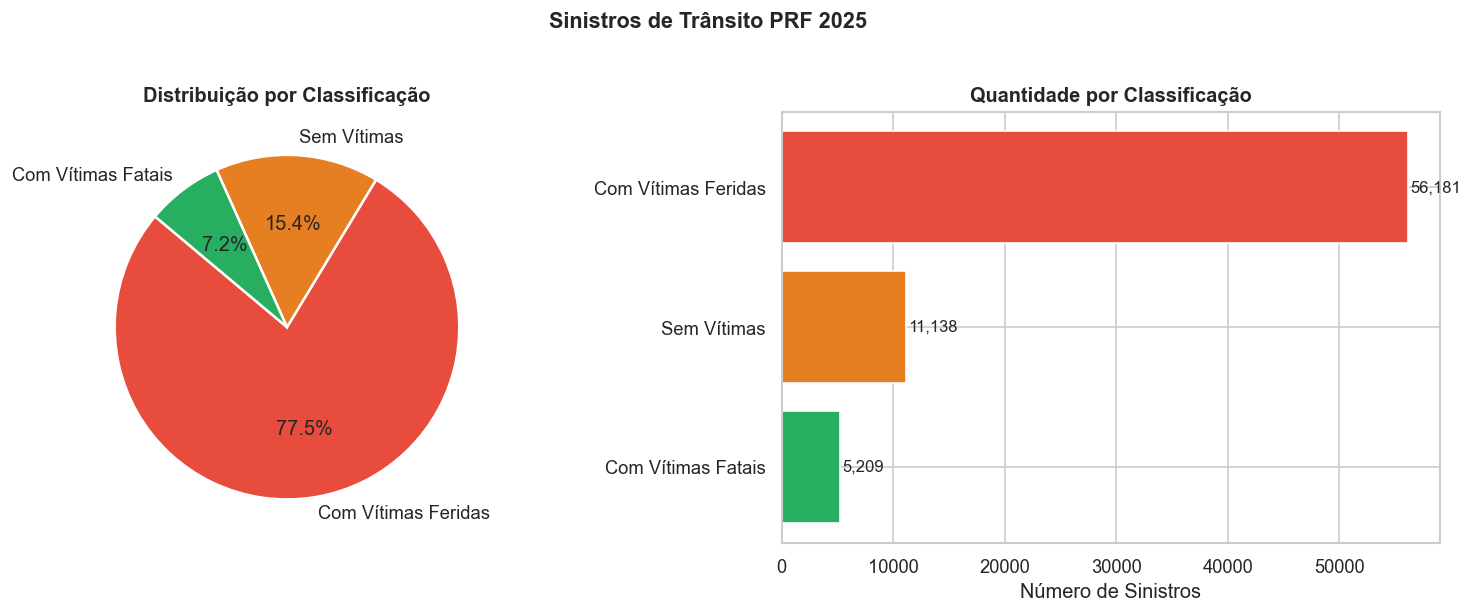

In [5]:
# Gráfico de distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pizza
contagem = df[COLUNA_ALVO].value_counts(dropna=True)
cores = ['#e74c3c', '#e67e22', '#27ae60']
axes[0].pie(
    contagem.values, labels=contagem.index,
    autopct='%1.1f%%', colors=cores,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Distribuição por Classificação', fontweight='bold')

# Barras
axes[1].barh(contagem.index, contagem.values, color=cores)
for i, v in enumerate(contagem.values):
    axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=10)
axes[1].set_xlabel('Número de Sinistros')
axes[1].set_title('Quantidade por Classificação', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Sinistros de Trânsito PRF 2025', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/distribuicao_alvo.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Análise das Features

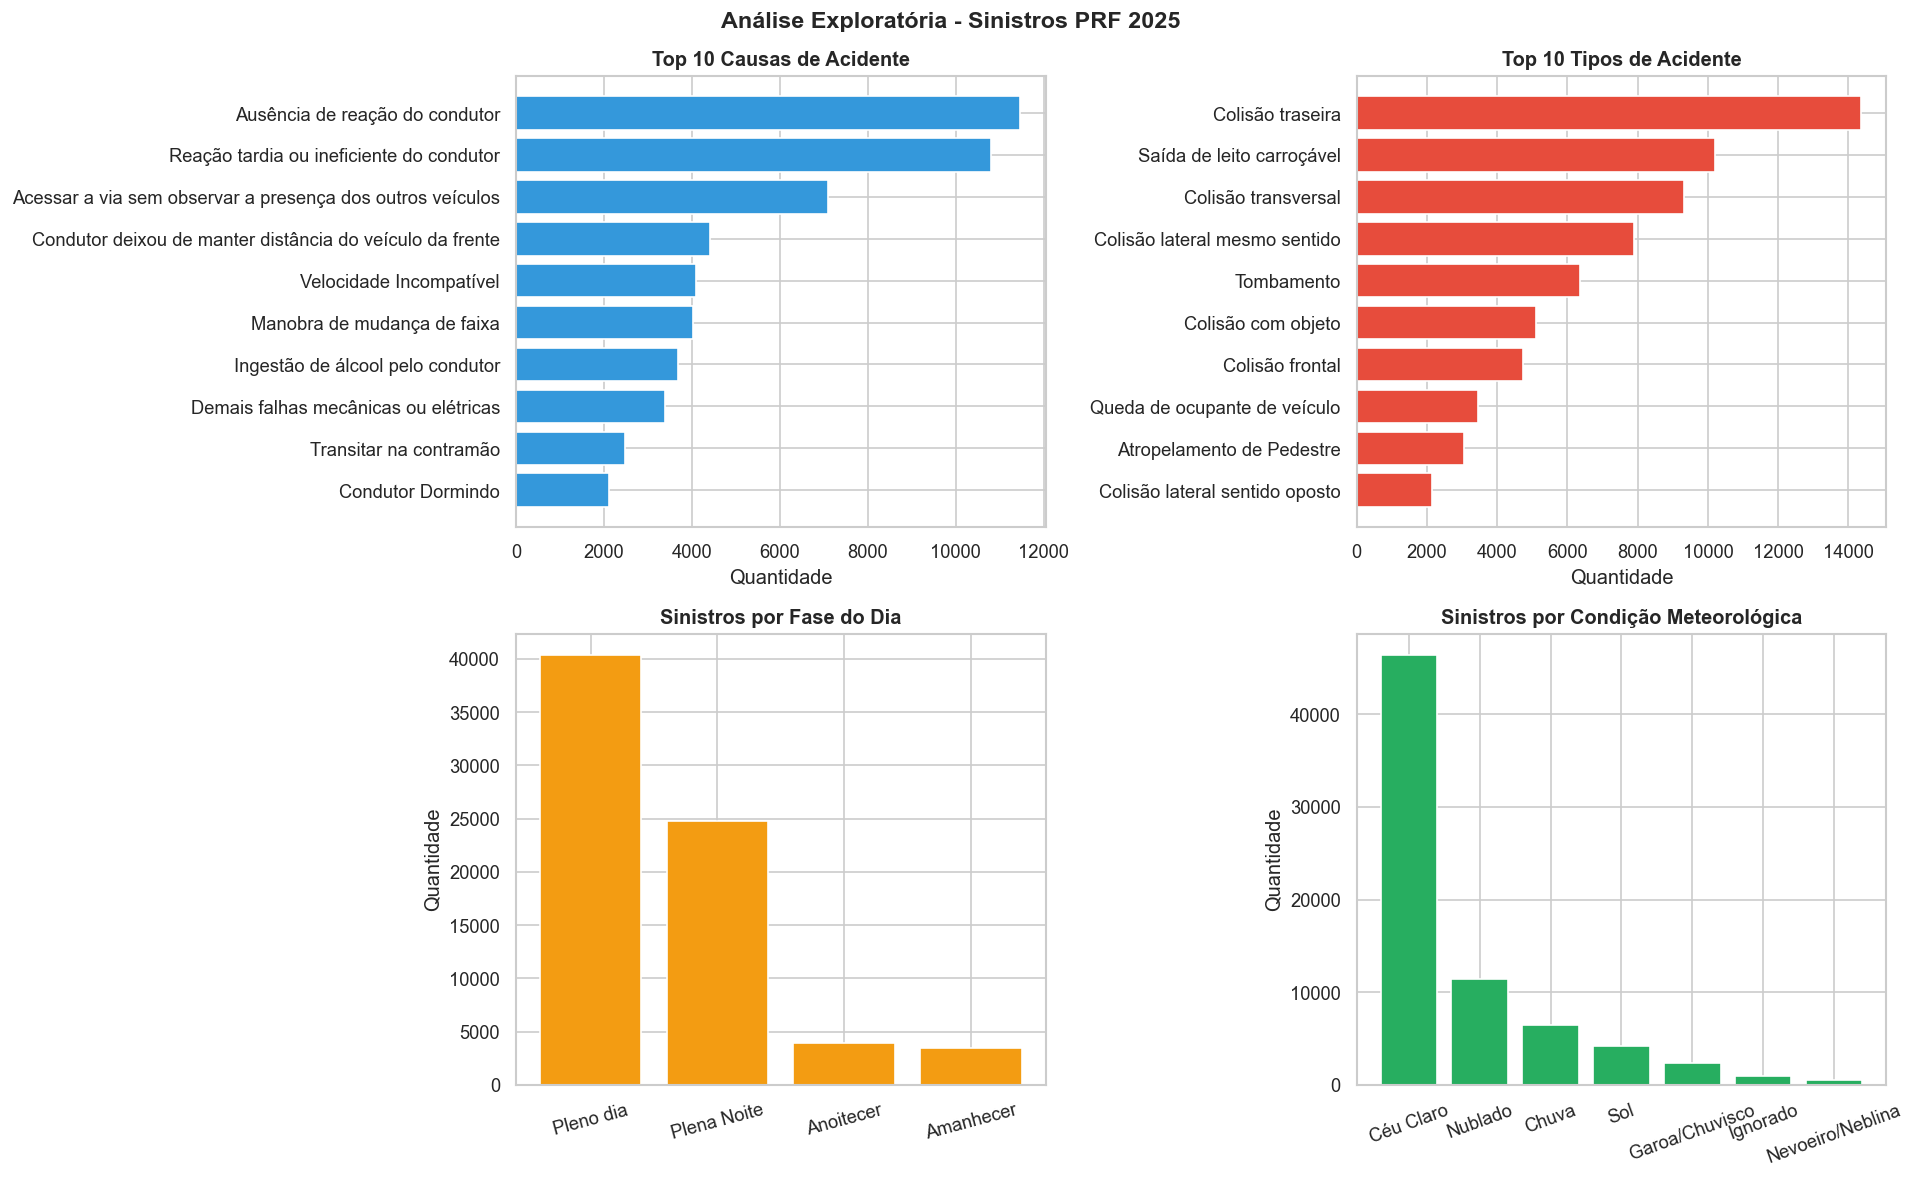

In [6]:
# Top causas de acidente
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Causa do acidente
top_causas = df['causa_acidente'].value_counts().head(10)
axes[0, 0].barh(top_causas.index[::-1], top_causas.values[::-1], color='#3498db')
axes[0, 0].set_title('Top 10 Causas de Acidente', fontweight='bold')
axes[0, 0].set_xlabel('Quantidade')

# Tipo de acidente
top_tipos = df['tipo_acidente'].value_counts().head(10)
axes[0, 1].barh(top_tipos.index[::-1], top_tipos.values[::-1], color='#e74c3c')
axes[0, 1].set_title('Top 10 Tipos de Acidente', fontweight='bold')
axes[0, 1].set_xlabel('Quantidade')

# Fase do dia
fase = df['fase_dia'].value_counts()
axes[1, 0].bar(fase.index, fase.values, color='#f39c12')
axes[1, 0].set_title('Sinistros por Fase do Dia', fontweight='bold')
axes[1, 0].set_ylabel('Quantidade')
axes[1, 0].tick_params(axis='x', rotation=15)

# Condição meteorológica
meteor = df['condicao_metereologica'].value_counts().head(7)
axes[1, 1].bar(meteor.index, meteor.values, color='#27ae60')
axes[1, 1].set_title('Sinistros por Condição Meteorológica', fontweight='bold')
axes[1, 1].set_ylabel('Quantidade')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.suptitle('Análise Exploratória - Sinistros PRF 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/analise_exploratoria.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Pré-processamento

### Estratégia:
1. **Remover** registros sem classificação (evitar ruído no treinamento)
2. **Binarizar** o alvo: `1 = Com Vítimas` / `0 = Sem Vítimas`
3. **Selecionar** apenas features sem data leakage (não usar mortos, feridos, etc)
4. **Codificar** categorias com `OneHotEncoder` (uma coluna binária por categoria)
5. **Dividir** em treino (80%) e teste (20%) com estratificação

> **Por que One-Hot e não Label Encoding?** As features são nominais (sem ordem natural). O `LabelEncoder` mapearia cada categoria para um inteiro arbitrário (0, 1, 2, …), criando uma ordem e distância falsas. Numa **árvore de decisão**, isso permite cortes em faixas de códigos sem sentido e **infla a importância de features com muitas categorias** (viés de cardinalidade). O One-Hot evita isso; em contrapartida, a importância passa a ser por coluna e precisará ser **reagregada por feature** (seção 6).

In [7]:
# --- Remover registros sem classificação ---
df_clean = df.dropna(subset=[COLUNA_ALVO]).copy()
print(f'Registros originais  : {len(df):,}')
print(f'Registros utilizados : {len(df_clean):,}')
print(f'Removidos (sem alvo) : {len(df) - len(df_clean)}')

# --- Target binário ---
df_clean['com_vitimas'] = df_clean[COLUNA_ALVO].apply(
    lambda x: 1 if x in ('Com Vítimas Feridas', 'Com Vítimas Fatais') else 0
)

print(f'\nDistribuição do target binário:')
print(df_clean['com_vitimas']
      .value_counts()
      .rename({1: 'Com Vítimas (1)', 0: 'Sem Vítimas (0)'})
      .to_string())
print(f'\nDesbalanceamento: {df_clean["com_vitimas"].mean()*100:.1f}% com vítimas')

Registros originais  : 72,529
Registros utilizados : 72,528
Removidos (sem alvo) : 1

Distribuição do target binário:
com_vitimas
Com Vítimas (1)    61390
Sem Vítimas (0)    11138

Desbalanceamento: 84.6% com vítimas


In [8]:
# --- Codificação One-Hot ---
X_raw = df_clean[FEATURES].fillna('Ignorado').astype(str)
y = df_clean['com_vitimas']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_arr = ohe.fit_transform(X_raw)
encoded_cols = list(ohe.get_feature_names_out(FEATURES))
X_enc = pd.DataFrame(X_arr, columns=encoded_cols, index=X_raw.index)

# Mapa coluna codificada -> feature original (para reagregar a importância depois)
col_to_feature = {}
idx = 0
for feat, cats in zip(FEATURES, ohe.categories_):
    for _ in cats:
        col_to_feature[encoded_cols[idx]] = feat
        idx += 1

print(f'One-Hot aplicado: {len(FEATURES)} features -> {X_enc.shape[1]} colunas binárias\n')
for feat, cats in zip(FEATURES, ohe.categories_):
    amostra = list(cats[:4])
    reticencias = '...' if len(cats) > 4 else ''
    print(f'  {feat:<32}: {len(cats):>3} categorias  {amostra}{reticencias}')

One-Hot aplicado: 10 features -> 746 colunas binárias

  dia_semana                      :   7 categorias  ['domingo', 'quarta-feira', 'quinta-feira', 'segunda-feira']...
  fase_dia                        :   4 categorias  ['Amanhecer', 'Anoitecer', 'Plena Noite', 'Pleno dia']
  condicao_metereologica          :   9 categorias  ['Chuva', 'Céu Claro', 'Garoa/Chuvisco', 'Ignorado']...
  tipo_pista                      :   3 categorias  ['Dupla', 'Múltipla', 'Simples']
  tracado_via                     : 605 categorias  ['Aclive', 'Aclive;Curva', 'Aclive;Curva;Em Obras', 'Aclive;Curva;Interseção de Vias']...
  causa_acidente                  :  69 categorias  ['Acessar a via sem observar a presença dos outros veículos', 'Acesso irregular', 'Acostamento em desnível', 'Acumulo de areia ou detritos sobre o pavimento']...
  tipo_acidente                   :  17 categorias  ['Atropelamento de Animal', 'Atropelamento de Pedestre', 'Capotamento', 'Colisão com objeto']...
  uso_solo              

In [9]:
# --- Split treino / teste estratificado ---
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Treino : {len(X_train):,} registros ({int((1-TEST_SIZE)*100)}%)')
print(f'Teste  : {len(X_test):,} registros ({int(TEST_SIZE*100)}%)')
print(f'\nProporção de "Com Vítimas" no treino: {y_train.mean()*100:.1f}%')
print(f'Proporção de "Com Vítimas" no teste:  {y_test.mean()*100:.1f}%')

Treino : 58,022 registros (80%)
Teste  : 14,506 registros (20%)

Proporção de "Com Vítimas" no treino: 84.6%
Proporção de "Com Vítimas" no teste:  84.6%


---
## 4. Treinamento da Árvore de Decisão

### Fundamento Teórico

O algoritmo utiliza **Entropia** como medida de impureza:

$$Entropia(S) = -\sum_{i=1}^{c} p_i \log_2 p_i$$

E seleciona a cada nó o atributo com maior **Ganho de Informação**:

$$IG(S, A) = Entropia(S) - \sum_{x \in P(A)} \frac{|S_x|}{|S|} \cdot Entropia(S_x)$$

### Hiperparâmetros
| Parâmetro | Valor | Justificativa |
|---|---|---|
| `criterion` | `'entropy'` | Usa Ganho de Informação (IG), conforme exigido |
| `max_depth` | `7` | Equilíbrio entre profundidade e overfitting |
| `min_samples_leaf` | `50` | Garante relevância estatística de cada folha |
| `random_state` | `42` | Reprodutibilidade |

In [10]:
modelo = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE
)

modelo.fit(X_train, y_train)

print('Modelo treinado com sucesso!')
print(f'  Nós na árvore     : {modelo.tree_.node_count}')
print(f'  Profundidade real : {modelo.get_depth()}')
print(f'  Folhas            : {modelo.get_n_leaves()}')

Modelo treinado com sucesso!
  Nós na árvore     : 85
  Profundidade real : 7
  Folhas            : 43


---
## 5. Avaliação do Modelo

In [11]:
# Acurácia no treino e no teste
acc_treino = accuracy_score(y_train, modelo.predict(X_train))
acc_teste  = accuracy_score(y_test,  modelo.predict(X_test))

print(f'Acurácia no Treino : {acc_treino:.4f} ({acc_treino*100:.2f}%)')
print(f'Acurácia no Teste  : {acc_teste:.4f} ({acc_teste*100:.2f}%)')

gap = (acc_treino - acc_teste) * 100
print(f'Diferença          : {gap:.2f}%')
print(f'\nAvaliação de overfitting: {"OK - sem overfitting significativo" if gap < 3 else f"Atenção: diferença de {gap:.1f}%"}')

Acurácia no Treino : 0.8708 (87.08%)


Acurácia no Teste  : 0.8676 (86.76%)
Diferença          : 0.31%

Avaliação de overfitting: OK - sem overfitting significativo


In [12]:
# Relatório de classificação completo
y_pred = modelo.predict(X_test)
print('Relatório de Classificação (conjunto de teste):')
print(classification_report(
    y_test, y_pred,
    target_names=['Sem Vítimas', 'Com Vítimas']
))

Relatório de Classificação (conjunto de teste):
              precision    recall  f1-score   support

 Sem Vítimas       0.95      0.15      0.25      2228
 Com Vítimas       0.87      1.00      0.93     12278

    accuracy                           0.87     14506
   macro avg       0.91      0.57      0.59     14506
weighted avg       0.88      0.87      0.82     14506



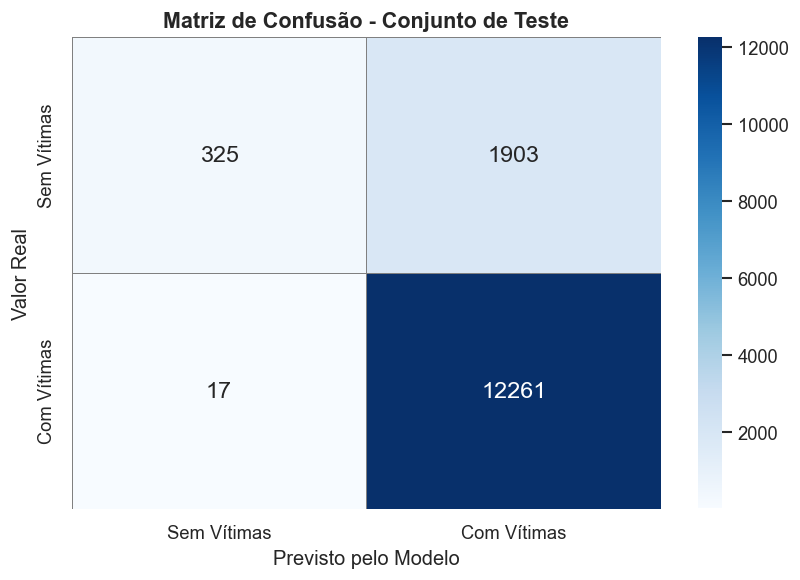


Verdadeiros Negativos (Sem Vítimas correto) : 325
Falsos Positivos (Sem → previsto Com)       : 1,903
Falsos Negativos (Com → previsto Sem)       : 17
Verdadeiros Positivos (Com Vítimas correto) : 12,261


In [13]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Sem Vítimas', 'Com Vítimas']
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=labels, yticklabels=labels,
    cmap='Blues', ax=ax,
    linewidths=0.5, linecolor='gray',
    annot_kws={'size': 14}
)
ax.set_xlabel('Previsto pelo Modelo', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_title('Matriz de Confusão - Conjunto de Teste', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nVerdadeiros Negativos (Sem Vítimas correto) : {tn:,}')
print(f'Falsos Positivos (Sem → previsto Com)       : {fp:,}')
print(f'Falsos Negativos (Com → previsto Sem)       : {fn:,}')
print(f'Verdadeiros Positivos (Com Vítimas correto) : {tp:,}')

---
## 6. Importância das Features

A importância de cada feature é calculada como a **redução total de entropia** (impureza) ponderada pelo número de amostras que passam por cada nó onde aquele atributo foi usado para a divisão.

In [14]:
# A importância nativa do modelo é POR COLUNA one-hot (ex.: 'tipo_acidente_Colisão...').
# Reagregamos somando as colunas de cada feature original -> importância POR FEATURE.
imp_col  = pd.Series(modelo.feature_importances_, index=encoded_cols)
imp_feat = imp_col.groupby(col_to_feature).sum().reindex(FEATURES).fillna(0.0)

importancias = (imp_feat.rename('importancia')
                .reset_index().rename(columns={'index': 'feature'})
                .sort_values('importancia', ascending=False)
                .reset_index(drop=True))
importancias['rank'] = importancias.index + 1
importancias['importancia_pct'] = importancias['importancia'] * 100

print('Ranking de Importância das Features (reagregada por feature original):')
print(f'{"Rank":<5} {"Feature":<32} {"Importância":>12} {"Acumulado":>10}')
print('-' * 65)
acumulado = 0
for _, row in importancias.iterrows():
    acumulado += row['importancia_pct']
    print(f"  {int(row['rank']):<4} {row['feature']:<32} "
          f"{row['importancia_pct']:>10.2f}%  {acumulado:>8.1f}%")

Ranking de Importância das Features (reagregada por feature original):
Rank  Feature                           Importância  Acumulado
-----------------------------------------------------------------
  1    tipo_acidente                         78.47%      78.5%
  2    causa_acidente                        15.40%      93.9%
  3    sentido_via                            2.63%      96.5%
  4    fase_dia                               1.70%      98.2%
  5    uf                                     1.22%      99.4%
  6    uso_solo                               0.25%      99.7%
  7    condicao_metereologica                 0.20%      99.9%
  8    tipo_pista                             0.11%     100.0%
  9    tracado_via                            0.02%     100.0%
  10   dia_semana                             0.00%     100.0%


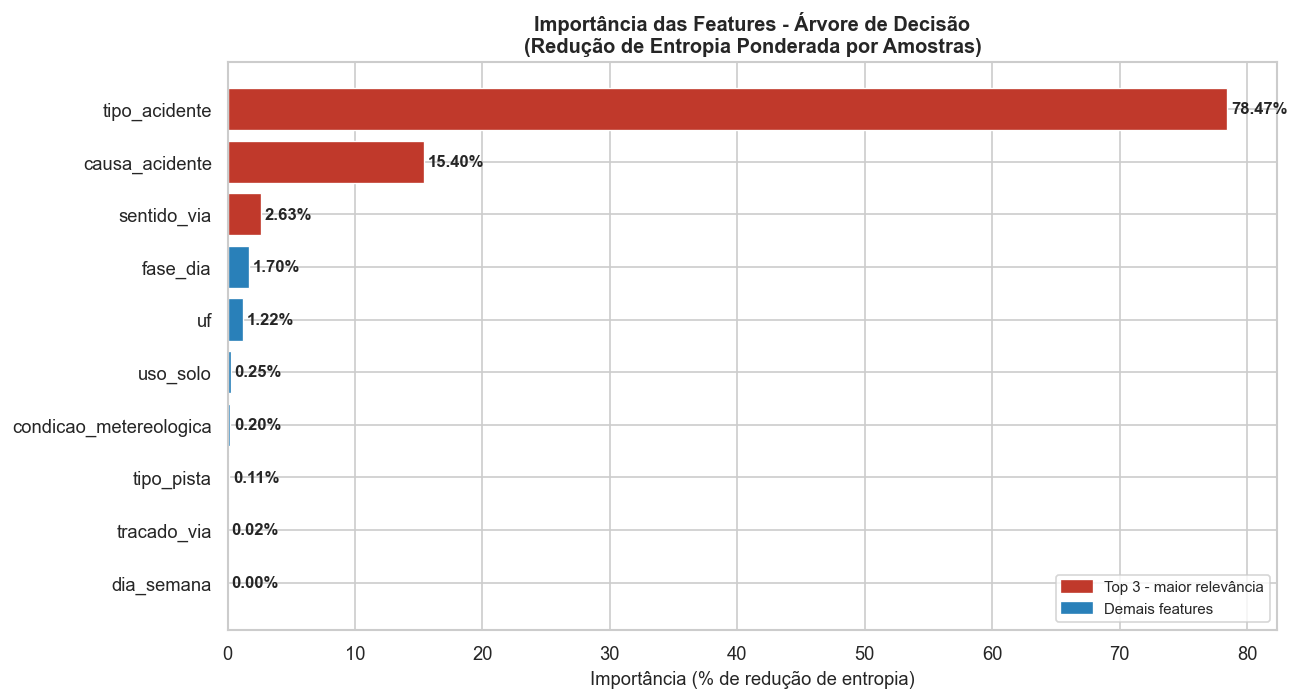

In [15]:
# Gráfico de importância
fig, ax = plt.subplots(figsize=(11, 6))
cores = ['#c0392b' if i < 3 else '#2980b9' for i in range(len(importancias))]

bars = ax.barh(
    importancias['feature'][::-1],
    importancias['importancia_pct'][::-1],
    color=cores[::-1], edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, importancias['importancia_pct'][::-1]):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%', va='center', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Importância (% de redução de entropia)', fontsize=11)
ax.set_title(
    'Importância das Features - Árvore de Decisão\n'
    '(Redução de Entropia Ponderada por Amostras)',
    fontsize=12, fontweight='bold'
)
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color='#c0392b', label='Top 3 - maior relevância'),
        plt.Rectangle((0, 0), 1, 1, color='#2980b9', label='Demais features'),
    ],
    loc='lower right', fontsize=9
)
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Visualização da Árvore de Decisão

A árvore completa tem profundidade 7. Abaixo visualizamos os primeiros **3 níveis** para legibilidade.

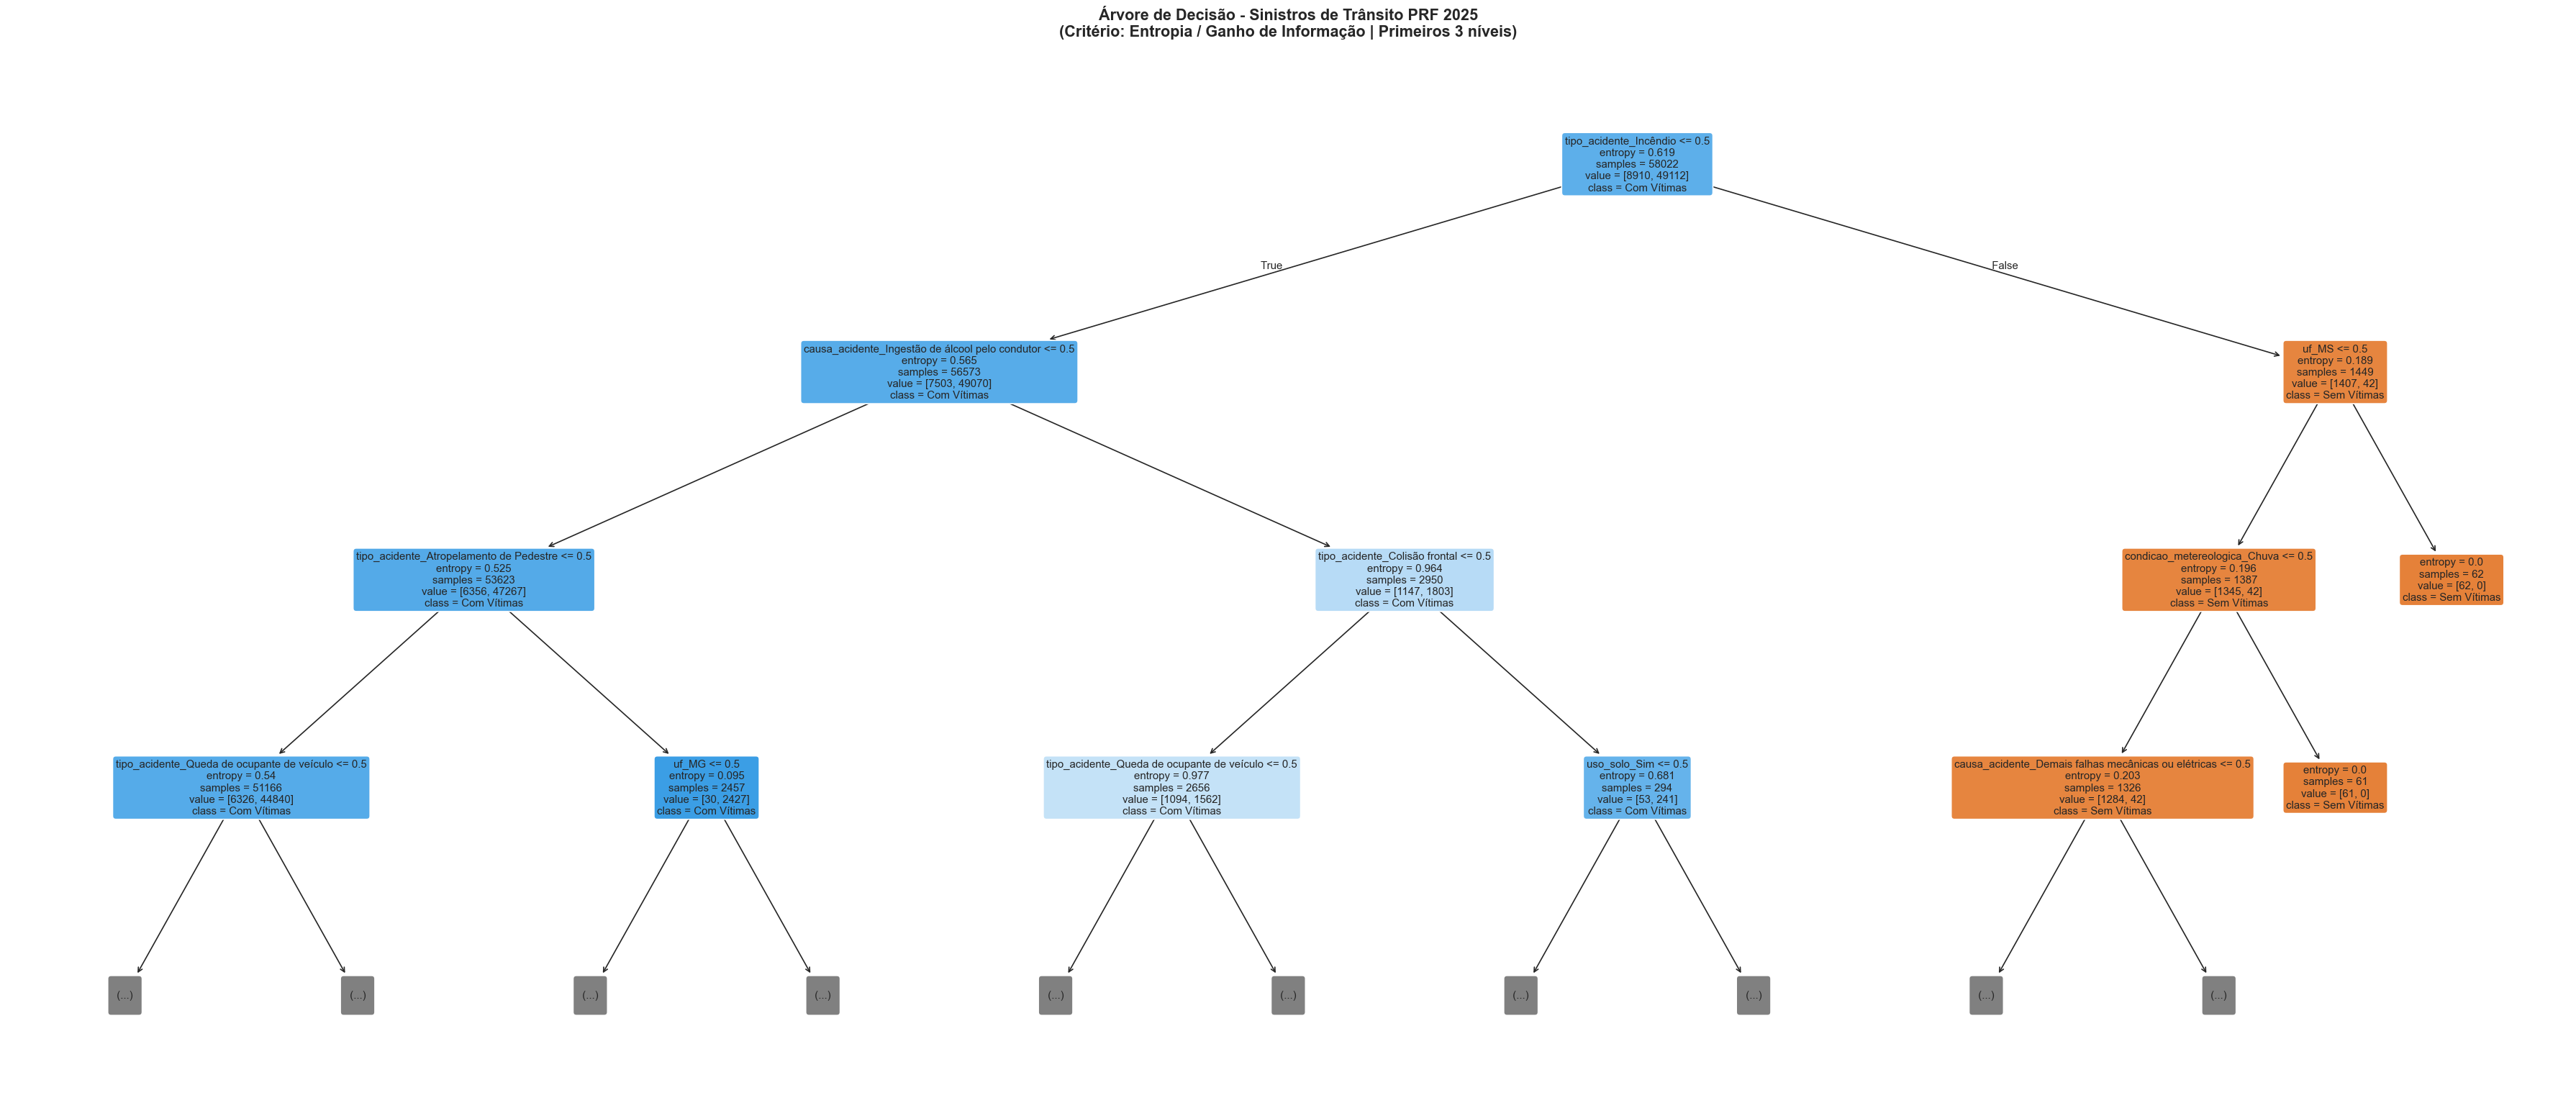

In [16]:
fig, ax = plt.subplots(figsize=(30, 13))
plot_tree(
    modelo,
    feature_names=encoded_cols,
    class_names=['Sem Vítimas', 'Com Vítimas'],
    filled=True,
    rounded=True,
    max_depth=3,        # exibe 3 níveis para visualização limpa
    fontsize=9,
    ax=ax,
    impurity=True       # exibe entropia de cada nó
)
ax.set_title(
    'Árvore de Decisão - Sinistros de Trânsito PRF 2025\n'
    '(Critério: Entropia / Ganho de Informação | Primeiros 3 níveis)',
    fontsize=13, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('output/arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Regras da árvore em formato texto (primeiros 2 níveis)
print('REGRAS DA ÁRVORE (primeiros 2 níveis):')
print('='*60)
print(export_text(modelo, feature_names=encoded_cols, max_depth=2))

REGRAS DA ÁRVORE (primeiros 2 níveis):
|--- tipo_acidente_Incêndio <= 0.50
|   |--- causa_acidente_Ingestão de álcool pelo condutor <= 0.50
|   |   |--- tipo_acidente_Atropelamento de Pedestre <= 0.50
|   |   |   |--- truncated branch of depth 5
|   |   |--- tipo_acidente_Atropelamento de Pedestre >  0.50
|   |   |   |--- truncated branch of depth 5
|   |--- causa_acidente_Ingestão de álcool pelo condutor >  0.50
|   |   |--- tipo_acidente_Colisão frontal <= 0.50
|   |   |   |--- truncated branch of depth 5
|   |   |--- tipo_acidente_Colisão frontal >  0.50
|   |   |   |--- truncated branch of depth 4
|--- tipo_acidente_Incêndio >  0.50
|   |--- uf_MS <= 0.50
|   |   |--- condicao_metereologica_Chuva <= 0.50
|   |   |   |--- truncated branch of depth 5
|   |   |--- condicao_metereologica_Chuva >  0.50
|   |   |   |--- class: 0
|   |--- uf_MS >  0.50
|   |   |--- class: 0



---
## 8. Análise dos Resultados e Proposta de Campanhas Educativas

Com base nos atributos identificados pelo modelo como mais relevantes para explicar a ocorrência de vítimas nos sinistros, propõem-se as seguintes campanhas educativas:

In [18]:
top5 = importancias.head(5)

mapa_campanhas = {
    'causa_acidente': {
        'nome': "DIRIJA COM ATENÇÃO",
        'foco': "Comportamento do condutor (distração, reação tardia, álcool, velocidade)",
        'acoes': [
            "Blitze educativas nas rodovias com maior incidência",
            "Parceria com autoescolas e aplicativos de navegação (alertas contextuais)",
            "Campanha nas redes sociais com dados reais de sinistros",
            "Educação em escolas e universidades sobre direção defensiva"
        ],
        'alvo': "Condutores em geral, especialmente jovens de 18 a 30 anos"
    },
    'tipo_acidente': {
        'nome': "DISTÂNCIA SEGURA SALVA VIDAS",
        'foco': "Prevenção de colisões traseiras, frontais e saídas de pista",
        'acoes': [
            "Painéis eletrônicos nas rodovias exibindo distância segura recomendada",
            "Fiscalização de ultrapassagem proibida com câmeras inteligentes",
            "Treinamento específico para motoristas de veículos pesados"
        ],
        'alvo': "Motoristas de caminhões, ônibus e veículos de carga"
    },
    'tracado_via': {
        'nome': "CURVAS PERIGOSAS - REDUZA A VELOCIDADE",
        'foco': "Trechos de curva, declive e aclive com maior incidência de sinistros",
        'acoes': [
            "Reforço de sinalização vertical e horizontal em curvas críticas",
            "Instalação de radares e redutores de velocidade nos pontos de risco",
            "Mapas de risco disponíveis em apps de navegação (Waze, Google Maps)"
        ],
        'alvo': "Todos os condutores em rodovias de relevo acentuado"
    },
    'fase_dia': {
        'nome': "NOITE EXIGE MAIS CUIDADO",
        'foco': "Plena noite e madrugada - menor visibilidade e maior fadiga",
        'acoes': [
            "Programas de descanso obrigatório em postos rodoviários homologados",
            "Alertas luminosos em regiões de alta incidência noturna",
            "Campanhas sobre uso de faróis e revisão de sistema de iluminação"
        ],
        'alvo': "Caminhoneiros, motoristas de aplicativo e viajantes noturnos"
    },
    'condicao_metereologica': {
        'nome': "CHUVA - REDUZA A VELOCIDADE",
        'foco': "Condições climáticas adversas: chuva, garoa, neblina",
        'acoes': [
            "Alertas em tempo real via apps e painéis de mensagem variável",
            "Treinamento sobre direção defensiva em piso molhado",
            "Campanha de verificação de pneus e sistema de freios"
        ],
        'alvo': "Todos os condutores, com destaque para regiões de clima úmido"
    },
    'tipo_pista': {
        'nome': "PISTAS SIMPLES - MÁXIMA ATENÇÃO",
        'foco': "Rodovias de pista simples com maior risco de colisão frontal",
        'acoes': [
            "Proibição reforçada de ultrapassagem com sinalização clara",
            "Demarcação de faixas de ultrapassagem segura",
            "Pressão política pela duplicação dos trechos mais críticos"
        ],
        'alvo': "Condutores e gestores de infraestrutura rodoviária"
    },
    'uso_solo': {
        'nome': "ZONA RURAL - ATENÇÃO REDOBRADA",
        'foco': "Áreas rurais onde sinistros tendem a ser mais graves",
        'acoes': [
            "Sinalização de travessias em acesso a propriedades rurais",
            "Redutores de velocidade em vias de acesso",
            "Educação de comunidades ribeirinhas às rodovias"
        ],
        'alvo': "Condutores e comunidades rurais lindeiras às rodovias"
    },
    'dia_semana': {
        'nome': "FIM DE SEMANA SEGURO",
        'foco': "Fins de semana com maior concentração de sinistros",
        'acoes': [
            "Intensificação de blitze nas sextas, sábados e domingos",
            "Campanhas contra álcool ao volante em saídas de festas e shows",
            "Parceria com bares e casas noturnas para táxis e apps de transporte"
        ],
        'alvo': "Jovens adultos e motoristas de lazer"
    },
    'sentido_via': {
        'nome': "SENTIDO CORRETO - VIDA GARANTIDA",
        'foco': "Contramão e ultrapassagens indevidas",
        'acoes': [
            "Fiscalização com câmeras de monitoramento inteligente",
            "Educação sobre regras de preferência e sinalização"
        ],
        'alvo': "Condutores em rodovias de pista simples"
    },
    'uf': {
        'nome': "CAMPANHAS REGIONALIZADAS POR ESTADO",
        'foco': "Estados com maior concentração de sinistros com vítimas",
        'acoes': [
            "Parcerias entre SENATRAN e órgãos estaduais de trânsito",
            "Campanhas adaptadas ao perfil regional (clima, relevo, frota)"
        ],
        'alvo': "Órgãos gestores e condutores por estado"
    },
}

print('=' * 70)
print('PROPOSTA DE CAMPANHAS EDUCATIVAS - BASEADA EM DADOS (DATA-DRIVEN)')
print('=' * 70)
print()

for i, row in top5.iterrows():
    feat = row['feature']
    pct  = row['importancia_pct']
    camp = mapa_campanhas.get(feat, {'nome': feat, 'foco': '-', 'acoes': [], 'alvo': '-'})
    
    print(f"{'─'*70}")
    print(f"  [{i+1}] FEATURE: {feat.upper()} - Importância: {pct:.2f}%")
    print(f"  CAMPANHA: '{camp['nome']}'")
    print(f"  FOCO    : {camp['foco']}")
    print(f"  AÇÕES   :")
    for acao in camp['acoes']:
        print(f"           • {acao}")
    print(f"  PÚBLICO : {camp['alvo']}")
    print()

PROPOSTA DE CAMPANHAS EDUCATIVAS - BASEADA EM DADOS (DATA-DRIVEN)

──────────────────────────────────────────────────────────────────────
  [1] FEATURE: TIPO_ACIDENTE - Importância: 78.47%
  CAMPANHA: 'DISTÂNCIA SEGURA SALVA VIDAS'
  FOCO    : Prevenção de colisões traseiras, frontais e saídas de pista
  AÇÕES   :
           • Painéis eletrônicos nas rodovias exibindo distância segura recomendada
           • Fiscalização de ultrapassagem proibida com câmeras inteligentes
           • Treinamento específico para motoristas de veículos pesados
  PÚBLICO : Motoristas de caminhões, ônibus e veículos de carga

──────────────────────────────────────────────────────────────────────
  [2] FEATURE: CAUSA_ACIDENTE - Importância: 15.40%
  CAMPANHA: 'DIRIJA COM ATENÇÃO'
  FOCO    : Comportamento do condutor (distração, reação tardia, álcool, velocidade)
  AÇÕES   :
           • Blitze educativas nas rodovias com maior incidência
           • Parceria com autoescolas e aplicativos de navegação (al

---
## 9. Conclusão

### Resumo dos Resultados

O modelo de **Árvore de Decisão** baseado em **Entropia e Ganho de Informação** foi capaz de:

1. **Identificar os atributos mais relevantes** para explicar a gravidade dos sinistros (com ou sem vítimas)
2. **Gerar regras interpretáveis** que podem ser compreendidas por gestores sem conhecimento técnico aprofundado
3. **Orientar campanhas educativas** com base em evidências reais extraídas dos dados da PRF

### Vantagens do Modelo para Políticas Públicas

| Característica | Benefício |
|---|---|
| Interpretabilidade | Regras SE-ENTÃO facilmente comunicáveis |
| Identificação de padrões | Revela combinações de fatores críticos |
| Priorização de recursos | Foca campanhas nos atributos de maior impacto |
| Atualização contínua | Pode ser retreinado com novos dados a cada ano |

In [19]:
print('Análise concluída!')
print(f'Imagens salvas na pasta output/')
print(f'\nArquivos gerados:')
for f in os.listdir('output'):
    print(f'  output/{f}')

Análise concluída!
Imagens salvas na pasta output/

Arquivos gerados:
  output/analise_exploratoria.png
  output/arvore_decisao.png
  output/distribuicao_alvo.png
  output/feature_importance.png
  output/matriz_confusao.png
